In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import re
import string

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.metrics.pairwise import cosine_similarity

In [3]:
df = pd.read_csv(
    "../dataset/Resume.csv"
)

df.head()

,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR


In [4]:
df.columns

Index(['ID', 'Resume_str', 'Resume_html', 'Category'], dtype='str')

In [5]:
import re
import string

def clean_text(text):

    text = str(text).lower()

    text = re.sub(
        f"[{string.punctuation}]",
        "",
        text
    )

    text = re.sub(
        r"\d+",
        "",
        text
    )

    return text

In [6]:
df["Clean_Resume"] = df["Resume_str"].apply(
    clean_text
)

df[[
    "Resume_str",
    "Clean_Resume"
]].head()

,Resume_str,Clean_Resume
0,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,hr administratormarketing associate\n...
1,"HR SPECIALIST, US HR OPERATIONS ...",hr specialist us hr operations ...
2,HR DIRECTOR Summary Over 2...,hr director summary over ...
3,HR SPECIALIST Summary Dedica...,hr specialist summary dedica...
4,HR MANAGER Skill Highlights ...,hr manager skill highlights ...


In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=5000
)

resume_vectors = vectorizer.fit_transform(
    df["Clean_Resume"]
)

In [8]:
job_description = """
Machine Learning
Python
Data Science
Deep Learning
NLP
TensorFlow
Scikit-learn
Data Analysis
SQL
Artificial Intelligence
"""

In [9]:
job_vector = vectorizer.transform(
    [job_description]
)

In [10]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_scores = cosine_similarity(
    resume_vectors,
    job_vector
)

In [11]:
df["Match_Score"] = similarity_scores

In [12]:
ranked_candidates = df.sort_values(
    by="Match_Score",
    ascending=False
)

ranked_candidates[[
    "Category",
    "Match_Score"
]].head(10)

,Category,Match_Score
1218,CONSULTANT,0.295814
1762,ENGINEERING,0.293214
2153,BANKING,0.251726
1339,AUTOMOBILE,0.208800
1303,DIGITAL-MEDIA,0.205509
2291,ARTS,0.204255
1142,CONSULTANT,0.203160
331,INFORMATION-TECHNOLOGY,0.199072
929,AGRICULTURE,0.194245
194,DESIGNER,0.193774


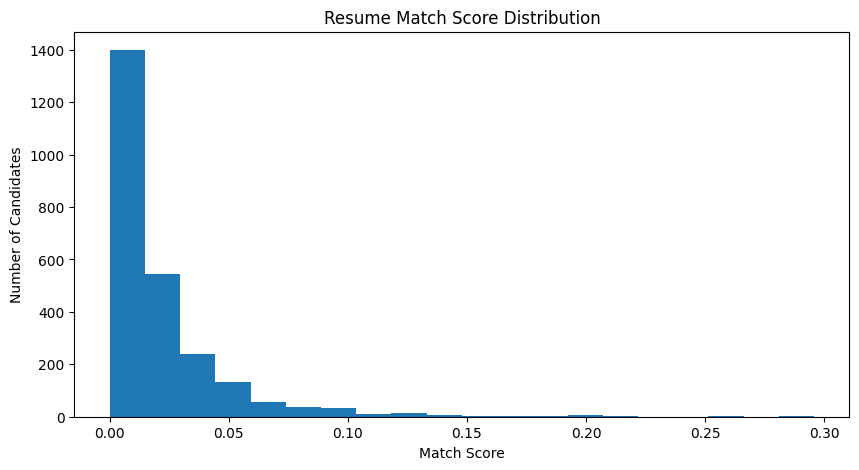

In [13]:
plt.figure(figsize=(10,5))

plt.hist(
    df["Match_Score"],
    bins=20
)

plt.title(
    "Resume Match Score Distribution"
)

plt.xlabel(
    "Match Score"
)

plt.ylabel(
    "Number of Candidates"
)

plt.show()

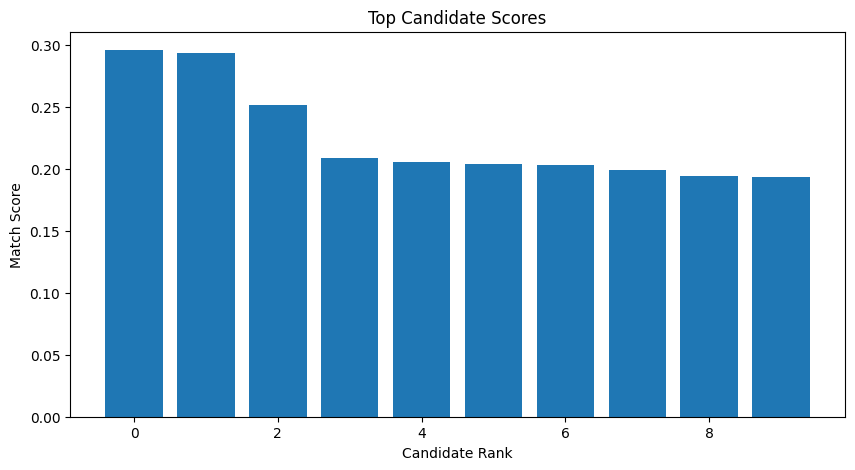

In [14]:
top_candidates = ranked_candidates.head(10)

plt.figure(figsize=(10,5))

plt.bar(
    range(len(top_candidates)),
    top_candidates["Match_Score"]
)

plt.title(
    "Top Candidate Scores"
)

plt.xlabel(
    "Candidate Rank"
)

plt.ylabel(
    "Match Score"
)

plt.show()

In [15]:
skills_required = {
    "python",
    "machine learning",
    "sql",
    "nlp",
    "tensorflow"
}

In [16]:
candidate_resume = ranked_candidates.iloc[0][
    "Clean_Resume"
]

missing_skills = []

for skill in skills_required:

    if skill not in candidate_resume:

        missing_skills.append(skill)

print(
    "Missing Skills:",
    missing_skills
)

Missing Skills: ['tensorflow', 'nlp']


In [17]:
print(
    "Top Candidate Category:"
)

print(
    ranked_candidates.iloc[0]["Category"]
)

print()

print(
    "Match Score:"
)

print(
    ranked_candidates.iloc[0]["Match_Score"]
)

Top Candidate Category:
CONSULTANT

Match Score:
0.29581418903103174
